# Getting the data ready

In [2]:
import pandas as pd
import seaborn as sns


df = pd.read_csv('dataset_2.csv')

In [3]:
df.columns

Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool', 'Price'],
      dtype='str')

## Data visualization

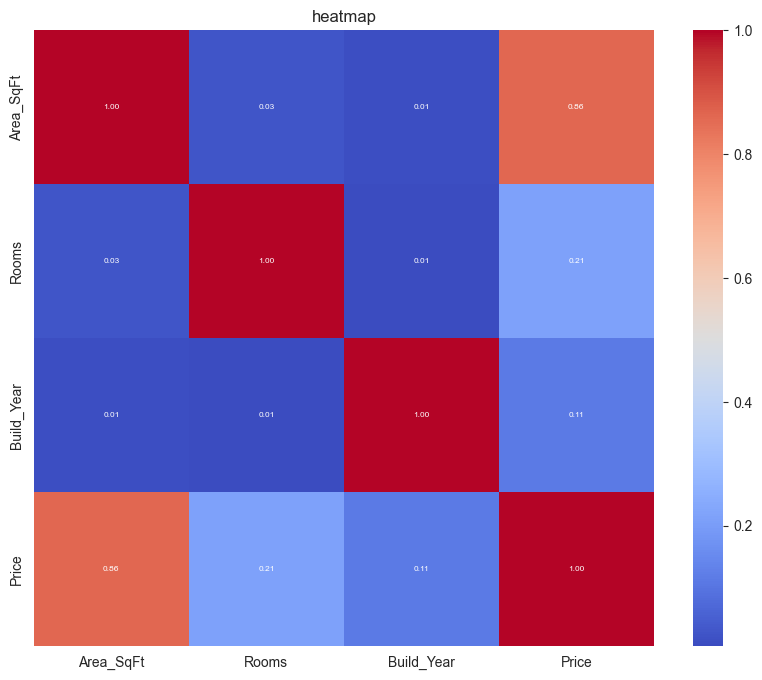

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot = True,
            cmap = 'coolwarm',
            fmt = '.2f',
            annot_kws={"size": 6})

plt.title('heatmap')
plt.show()

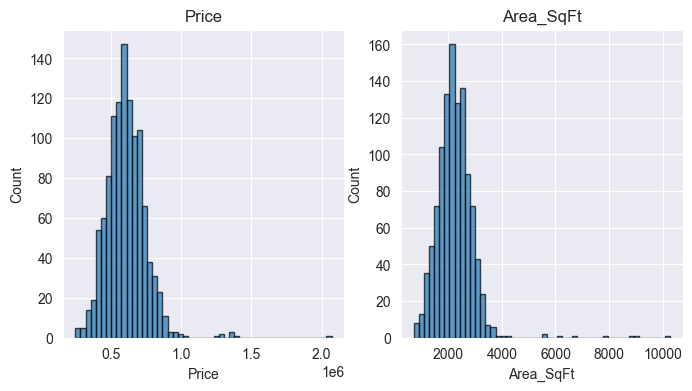

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
axes[0].hist(
		df["Price"],
		bins=50,
		edgecolor="black",
		alpha=0.7)
axes[0].set_title('Price')
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

axes[1].hist(
		df["Area_SqFt"],
		bins=50,
		edgecolor="black",
		alpha=0.7)
axes[1].set_title('Area_SqFt')

axes[1].set_xlabel("Area_SqFt")
axes[1].set_ylabel("Count")

plt.show()

In [6]:
import numpy as np

numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=['number']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Price'] = np.log1p(df['Price'])
df['Area_SqFt'] = np.log1p(df['Area_SqFt'])

df = pd.get_dummies(df)
df

,Area_SqFt,Rooms,Build_Year,Price,Location_Delhi,Location_Gurugram,Location_Indore,Location_Jaipur,Location_Kanpur,Location_Lucknow,...,Street_Type_Residential Lane,Furnishing_Furnished,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Property_Type_Apartment,Property_Type_Duplex,Property_Type_Independent House,Property_Type_Villa,Has_Pool_No,Has_Pool_Yes
0,7.813669,4.0,1992,13.250734,False,False,False,True,False,False,...,True,True,False,False,True,False,False,False,True,False
1,7.764072,4.0,2006,13.265970,False,False,True,False,False,False,...,False,False,False,True,True,False,False,False,False,True
2,7.702205,3.0,2012,13.273024,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
3,7.946223,6.0,1993,13.585613,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,True
4,7.534041,5.0,2012,13.108441,False,False,False,True,False,False,...,False,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1119,7.808749,7.0,1988,13.458730,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False
1120,8.177284,7.0,1989,13.509434,False,False,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
1121,7.687484,4.0,2011,13.187212,False,False,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
1122,7.697369,6.0,2022,13.187096,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False


# Training the models

In [7]:
!pip install catboost
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


X = df.drop('Price', axis = 1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

gbr = GradientBoostingRegressor(n_estimators = 1000,
                                learning_rate = 0.01,
                                max_depth = 6,
                                random_state=42)
gbr.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators = 1000,
                   learning_rate = 0.01,
                   max_depth = 6,
                   n_jobs = -1,
                   random_state=42,
                   reg_lambda=1)

xgb.fit(X_train, y_train)

cbr = CatBoostRegressor(n_estimators = 1000,
                        learning_rate = 0.01,
                        max_depth = 6,
                        thread_count = -1,
                        random_state=42,
                        l2_leaf_reg=5,
                        verbose = False)
cbr.fit(X_train, y_train)

er = VotingRegressor([('gbr', gbr), ('xgb', xgb), ('cbr', cbr)])
er.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('gbr', ...), ('xgb', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[GradientBoost...ndom_state=42), XGBRegressor(...ree=None, ...), CatBoostRegre...verbose=False)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U31](25,)","['Area_SqFt','Rooms','Build_Year',...,'Property_Type_Villa','Has_Pool_No', 'Has_Pool_Yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,25
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'gbr': Gradi...erbose=False)}
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000


# Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

def evaluate(model, X_train, X_test, y_train, y_test):
    y_preds_real = np.expm1(model.predict(X_test))
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)

    overfitting = model.score(X_train, y_train)
    r2 = model.score(X_test, y_test)

    mae = mean_absolute_error(y_test_real, y_preds_real)
    mse = np.sqrt(mean_squared_error(y_test_real, y_preds_real))
    mape = (abs(y_test_real - y_preds_real) / y_test_real).mean() * 100
    cv = cross_val_score(er, X_train, y_train, cv = 5)

    return {
        'model': type(model).__name__,
        'overfitting (train R²)': round(overfitting, 4),
        'r2 (test)': round(r2, 4),
        'mae': round(mae, 2),
        'rmse': round(mse, 2),
        'mape': f'{round(mape, 2)}%',
        'cross_val': f'{cv.mean():.4f} ± {cv.std():.4f}'
    }

## VotingRegressor

In [10]:
evaluate(er, X_train, X_test, y_train, y_test)

{'model': 'VotingRegressor',
 'overfitting (train R²)': 0.9879,
 'r2 (test)': 0.9321,
 'mae': 24813.54,
 'rmse': np.float64(32611.65),
 'mape': '4.37%',
 'cross_val': '0.8926 ± 0.0165'}

## XGBoostRegressor

In [11]:
evaluate(xgb, X_train, X_test, y_train, y_test)

{'model': 'XGBRegressor',
 'overfitting (train R²)': 0.9935,
 'r2 (test)': 0.9169,
 'mae': 28163.52,
 'rmse': np.float64(37742.8),
 'mape': '4.87%',
 'cross_val': '0.8926 ± 0.0165'}

## CatBoostRegressor
(the best one)

In [12]:
evaluate(cbr, X_train, X_test, y_train, y_test)

{'model': 'CatBoostRegressor',
 'overfitting (train R²)': np.float64(0.9543),
 'r2 (test)': np.float64(0.9377),
 'mae': 23910.54,
 'rmse': np.float64(36288.89),
 'mape': '4.07%',
 'cross_val': '0.8926 ± 0.0165'}

## GradientBoostingRegressor

In [13]:
evaluate(gbr, X_train, X_test, y_train, y_test)

{'model': 'GradientBoostingRegressor',
 'overfitting (train R²)': 0.9967,
 'r2 (test)': 0.9143,
 'mae': 28055.21,
 'rmse': np.float64(37265.5),
 'mape': '4.91%',
 'cross_val': '0.8926 ± 0.0165'}

# Top 10 model features

In [14]:
def top_10_features(model, X):
  feature_dict = dict(zip(X.columns, model.feature_importances_))
  feature_X = pd.DataFrame(feature_dict, index = [0])
  feature_X.T.plot.bar(title = 'feature importance', legend = False)

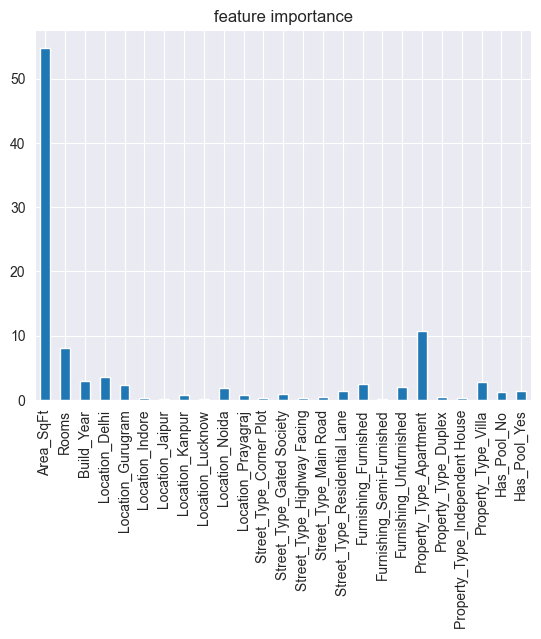

In [15]:
top_10_features(cbr, X)

# Save all models

In [16]:
import joblib

joblib.dump(er, 'VotingRegressor.pkl')
joblib.dump(cbr, 'CatBoostRegressor.pkl')
joblib.dump(xgb, 'XGBoostRegressor.pkl')
joblib.dump(gbr, 'GradientBoostingRegressor.pkl')

['GradientBoostingRegressor.pkl']